In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# Chargement des données
# MISE A JOUR (remarque 2, superviseur) : l'ancien filtre "annee == 2025"
# ne correspond plus a rien depuis le decalage de dates DYNAMIQUE (1c) --
# les donnees ne tombent plus dans une seule annee calendaire fixe.
# Remplace par une detection DONNEES-DRIVEN de la periode representative :
# le fichier brut contient en realite ~1 an de donnees denses (des milliers
# de contrats/semaine) precede d'une longue traine eparse (1-30 contrats/
# semaine, 0.05% du volume total) -- un artefact probable d'export
# "instantane des polices actives" ou les contrats de la 1ere annee ont
# deja expire/renouvele. Isole ici la region dense (semaines >100 lignes),
# et exclut le mois-frontiere partiel cree par la coupure semaine/mois.
df = pd.read_csv('processed_data/Production_Cleaned.csv', low_memory=False)
df['DEBUT_PERI'] = pd.to_datetime(df['DEBUT_PERI'], errors='coerce')

_weekly_counts = df.groupby(df['DEBUT_PERI'].dt.to_period('W')).size()
_dense_weeks = _weekly_counts[_weekly_counts > 100].index
n_sparse_rows = len(df) - df['DEBUT_PERI'].dt.to_period('W').isin(_dense_weeks).sum()
print(f"⚠️  Region eparse exclue : {n_sparse_rows} lignes sur {len(df)} "
      f"({n_sparse_rows/len(df)*100:.3f}%) -- non representative, voir commentaire ci-dessus.")
df = df[df['DEBUT_PERI'].dt.to_period('W').isin(_dense_weeks)]

df['Mois'] = df['DEBUT_PERI'].dt.to_period('M')
monthly = df.groupby('Mois')['PRIME_NETTE'].sum().reset_index()
monthly.columns = ['Mois', 'CA']
monthly['ds'] = monthly['Mois'].dt.to_timestamp()
monthly = monthly.sort_values('ds').reset_index(drop=True)

# Exclut le mois-frontiere partiel (coupure semaine/mois a la limite de la
# region dense -- un "mois" avec une seule semaine partielle de donnees a
# un CA artificiellement bas, pas un vrai mois incomplet cote business).
_before = len(monthly)
monthly = monthly[monthly['CA'] > 1e6].reset_index(drop=True)
if len(monthly) < _before:
    print(f"⚠️  {_before - len(monthly)} mois partiel(s) exclu(s) (effet de bord semaine/mois).")

print(f"✅ {len(monthly)} mois de données représentatives")
print(monthly[['ds', 'CA']])

⚠️  Region eparse exclue : 157 lignes sur 285736 (0.055%) -- non representative, voir commentaire ci-dessus.
⚠️  1 mois partiel(s) exclu(s) (effet de bord semaine/mois).
✅ 12 mois de données représentatives
           ds            CA
0  2025-08-01  1.548963e+07
1  2025-09-01  1.475326e+07
2  2025-10-01  1.535309e+07
3  2025-11-01  1.482047e+07
4  2025-12-01  1.497484e+07
5  2026-01-01  1.465939e+07
6  2026-02-01  1.376307e+07
7  2026-03-01  1.577455e+07
8  2026-04-01  1.669308e+07
9  2026-05-01  1.671754e+07
10 2026-06-01  1.596566e+07
11 2026-07-01  1.630431e+07


**Modèles retenus** : Naïf, Régression Linéaire, ETS, LSTM, Prophet.


In [2]:
# MODELE 0 : NAIF (reference) -- CA(t) = CA(t-1)
y = monthly['CA'].values
n = len(y)

naive_pred = y[:-1]
naive_true = y[1:]
naive_mae  = mean_absolute_error(naive_true, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(naive_true, naive_pred))
naive_r2   = r2_score(naive_true, naive_pred)

print(f"📊 Naif : MAE={naive_mae/1e6:.2f}M  RMSE={naive_rmse/1e6:.2f}M  R²={naive_r2:.3f}")

📊 Naif : MAE=0.66M  RMSE=0.84M  R²=0.131


In [3]:
# MODELE 1 : REGRESSION LINEAIRE SAISONNIERE
# Optuna + LOOCV : harmoniques + degre de tendance (seuls hyperparametres reels de ce modele)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def lr_features(ds_series, n_harmonics, trend_degree, t_offset=0):
    t = np.arange(t_offset, t_offset + len(ds_series))
    month = ds_series.dt.month.values
    cols = [t ** d for d in range(1, trend_degree + 1)]
    for h in range(1, n_harmonics + 1):
        cols.append(np.sin(2 * np.pi * h * month / 12))
        cols.append(np.cos(2 * np.pi * h * month / 12))
    return np.column_stack(cols)

def lr_loocv(n_harmonics, trend_degree):
    X_full = lr_features(monthly['ds'], n_harmonics, trend_degree)
    preds = np.zeros(n)
    for i in range(n):
        idx = [j for j in range(n) if j != i]
        m = LinearRegression().fit(X_full[idx], y[idx])
        preds[i] = m.predict(X_full[i:i + 1])[0]
    return mean_absolute_error(y, preds), np.sqrt(mean_squared_error(y, preds))

def lr_objective(trial):
    n_harmonics  = trial.suggest_int('n_harmonics', 1, 3)
    trend_degree = trial.suggest_int('trend_degree', 1, 2)
    mae, rmse = lr_loocv(n_harmonics, trend_degree)
    trial.set_user_attr('mae', mae)
    return rmse

lr_study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
lr_study.optimize(lr_objective, n_trials=20)
LR_HARMONICS    = lr_study.best_params['n_harmonics']
LR_TREND_DEGREE = lr_study.best_params['trend_degree']
print(f"Meilleure config : harmoniques={LR_HARMONICS}, degre_tendance={LR_TREND_DEGREE} "
      f"(LOOCV RMSE={lr_study.best_value/1e6:.2f}M TND)")

X_lr = lr_features(monthly['ds'], LR_HARMONICS, LR_TREND_DEGREE)
lr_model = LinearRegression().fit(X_lr, y)
lr_pred  = lr_model.predict(X_lr)
lr_mae   = mean_absolute_error(y, lr_pred)
lr_rmse  = np.sqrt(mean_squared_error(y, lr_pred))
lr_r2    = r2_score(y, lr_pred)
print(f"📊 Régression Linéaire : MAE={lr_mae/1e6:.2f}M  RMSE={lr_rmse/1e6:.2f}M  R²={lr_r2:.3f}")

Meilleure config : harmoniques=1, degre_tendance=1 (LOOCV RMSE=0.73M TND)
📊 Régression Linéaire : MAE=0.42M  RMSE=0.53M  R²=0.617


In [4]:
# MODELE 2 : ETS / HOLT-WINTERS (tendance seule -- pas assez d'historique pour une saisonnalite fiable)
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ets_model = ExponentialSmoothing(y, trend='add', seasonal=None, initialization_method='estimated').fit()
ets_pred  = ets_model.fittedvalues
ets_mae   = mean_absolute_error(y, ets_pred)
ets_rmse  = np.sqrt(mean_squared_error(y, ets_pred))
ets_r2    = r2_score(y, ets_pred)
print(f"📊 ETS : MAE={ets_mae/1e6:.2f}M  RMSE={ets_rmse/1e6:.2f}M  R²={ets_r2:.3f}")

📊 ETS : MAE=0.52M  RMSE=0.71M  R²=0.321


In [5]:
# MODELE 3 : LSTM (pytorch) -- demande explicitement par la superviseur
import torch
import torch.nn as nn

torch.manual_seed(42)
WINDOW = 4
series = y.astype(np.float32)
lstm_mean, lstm_std = series.mean(), series.std()
series_norm = (series - lstm_mean) / lstm_std

def make_windows(arr, window):
    X, Y = [], []
    for i in range(len(arr) - window):
        X.append(arr[i:i + window])
        Y.append(arr[i + window])
    return np.array(X), np.array(Y)

X_lstm, y_lstm = make_windows(series_norm, WINDOW)

class SmallLSTM(nn.Module):
    def __init__(self, hidden=4):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden, batch_first=True)
        self.drop = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x.unsqueeze(-1))
        return self.fc(self.drop(out[:, -1, :])).squeeze(-1)

lstm_model = SmallLSTM()
lstm_opt = torch.optim.Adam(lstm_model.parameters(), lr=0.02, weight_decay=1e-2)
Xt, Yt = torch.tensor(X_lstm, dtype=torch.float32), torch.tensor(y_lstm, dtype=torch.float32)
for _ in range(150):
    lstm_opt.zero_grad()
    loss = nn.MSELoss()(lstm_model(Xt), Yt)
    loss.backward()
    lstm_opt.step()

lstm_model.eval()
with torch.no_grad():
    lstm_pred_norm = lstm_model(Xt).numpy()
lstm_pred = lstm_pred_norm * lstm_std + lstm_mean
lstm_true = y[WINDOW:]
lstm_mae  = mean_absolute_error(lstm_true, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(lstm_true, lstm_pred))
lstm_r2   = r2_score(lstm_true, lstm_pred)
print(f"📊 LSTM ({len(lstm_true)}/{n} mois utilisables) : MAE={lstm_mae/1e6:.2f}M  RMSE={lstm_rmse/1e6:.2f}M  R²={lstm_r2:.3f}")

📊 LSTM (8/12 mois utilisables) : MAE=0.34M  RMSE=0.44M  R²=0.803


In [6]:
# MODELE 4 : PROPHET
# Optuna + LOOCV : changepoint_prior_scale, seasonality_prior_scale, fourier_order
def prophet_fit(train_df, cps, sps, fo):
    m = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False,
                seasonality_mode='additive', changepoint_prior_scale=cps, seasonality_prior_scale=sps)
    m.add_seasonality(name='monthly', period=30.5, fourier_order=fo)
    m.fit(train_df)
    return m

def prophet_loocv(cps, sps, fo):
    preds = np.zeros(n)
    for i in range(n):
        idx = [j for j in range(n) if j != i]
        train_i = monthly.iloc[idx][['ds', 'CA']].rename(columns={'CA': 'y'})
        m = prophet_fit(train_i, cps, sps, fo)
        preds[i] = m.predict(monthly.iloc[[i]][['ds']])['yhat'].values[0]
    return mean_absolute_error(y, preds), np.sqrt(mean_squared_error(y, preds))

def prophet_objective(trial):
    cps = trial.suggest_float('changepoint_prior_scale', 0.001, 0.5, log=True)
    sps = trial.suggest_float('seasonality_prior_scale', 0.01, 10, log=True)
    fo  = trial.suggest_int('fourier_order', 1, 4)
    mae, rmse = prophet_loocv(cps, sps, fo)
    trial.set_user_attr('mae', mae)
    return rmse

prophet_study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
prophet_study.optimize(prophet_objective, n_trials=15)
PROPHET_CPS = prophet_study.best_params['changepoint_prior_scale']
PROPHET_SPS = prophet_study.best_params['seasonality_prior_scale']
PROPHET_FO  = prophet_study.best_params['fourier_order']
print(f"Meilleure config : cps={PROPHET_CPS:.4f}, sps={PROPHET_SPS:.3f}, fourier_order={PROPHET_FO} "
      f"(LOOCV RMSE={prophet_study.best_value/1e6:.2f}M TND)")

df_prophet = monthly[['ds', 'CA']].rename(columns={'CA': 'y'})
prophet_model = prophet_fit(df_prophet, PROPHET_CPS, PROPHET_SPS, PROPHET_FO)
prophet_forecast = prophet_model.predict(df_prophet)
prophet_pred = prophet_forecast['yhat'].values
prophet_mae  = mean_absolute_error(y, prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(y, prophet_pred))
prophet_r2   = r2_score(y, prophet_pred)
print(f"📊 Prophet : MAE={prophet_mae/1e6:.2f}M  RMSE={prophet_rmse/1e6:.2f}M  R²={prophet_r2:.3f}")

17:33:16 - cmdstanpy - INFO - Chain [1] start processing


17:33:16 - cmdstanpy - INFO - Chain [1] done processing


17:33:16 - cmdstanpy - INFO - Chain [1] start processing


17:33:16 - cmdstanpy - INFO - Chain [1] done processing


17:33:17 - cmdstanpy - INFO - Chain [1] start processing


...

17:33:59 - cmdstanpy - INFO - Chain [1] done processing


17:33:59 - cmdstanpy - INFO - Chain [1] start processing


17:33:59 - cmdstanpy - INFO - Chain [1] done processing


Meilleure config : cps=0.0244, sps=0.599, fourier_order=1 (LOOCV RMSE=0.43M TND)


📊 Prophet : MAE=0.21M  RMSE=0.29M  R²=0.884


### Pourquoi Optuna n'est appliqué qu'à 2 modèles sur 5

Naïf n'a pas d'hyperparamètre. ETS n'a presque plus de choix libre une fois la saisonnalité
écartée. LSTM a déjà trop peu de données pour un tuning fiable (voir cellule ci-dessus).
Optuna est réservé à la Régression Linéaire et à Prophet : les deux seuls modèles avec un
hyperparamètre réellement significatif et des candidats plausibles pour la production.

=== (a) Intra-échantillon, à titre indicatif ===
             Modèle  MAE (M TND)  RMSE (M TND)    R²
               Naïf        0.662         0.836 0.131
Régression Linéaire        0.416         0.531 0.617
                ETS        0.523         0.707 0.321
               LSTM        0.339         0.437 0.803
            Prophet        0.209         0.293 0.884



17:34:00 - cmdstanpy - INFO - Chain [1] start processing


17:34:00 - cmdstanpy - INFO - Chain [1] done processing


17:34:00 - cmdstanpy - INFO - Chain [1] start processing


17:34:00 - cmdstanpy - INFO - Chain [1] done processing


...

17:34:02 - cmdstanpy - INFO - Chain [1] start processing


17:34:02 - cmdstanpy - INFO - Chain [1] done processing


17:34:02 - cmdstanpy - INFO - Chain [1] start processing


17:34:02 - cmdstanpy - INFO - Chain [1] done processing


=== (b) Backtest hors-échantillon, 5 prédictions -- LA comparaison qui fait foi ===
             Modèle  MAPE backtest (%)  n prédictions Classement
            Prophet               2.99              5          🥇
               Naïf               5.92              5          🥈
                ETS               6.34              5          🥉
               LSTM               7.83              5           
Régression Linéaire               8.81              5           


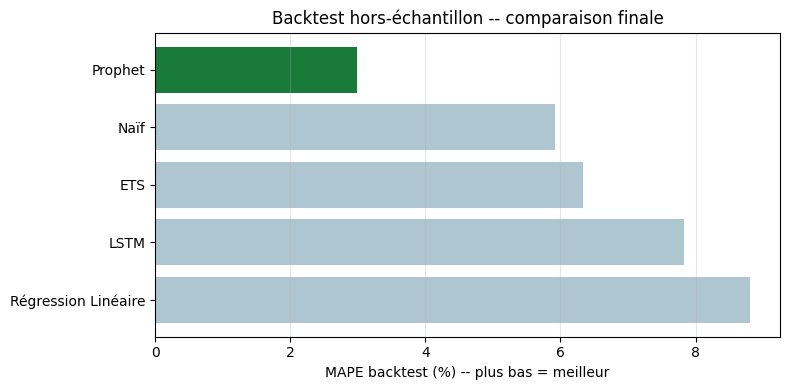

In [7]:
# COMPARAISON FINALE UNIFIEE -- les 5 modeles ensemble, en une seule section
MODEL_NAMES = ['Naïf', 'Régression Linéaire', 'ETS', 'LSTM', 'Prophet']

# (a) Intra-echantillon (indicatif seulement, voir plus haut)
insample = pd.DataFrame({
    'Modèle': MODEL_NAMES,
    'MAE (M TND)':  [v/1e6 for v in [naive_mae, lr_mae, ets_mae, lstm_mae, prophet_mae]],
    'RMSE (M TND)': [v/1e6 for v in [naive_rmse, lr_rmse, ets_rmse, lstm_rmse, prophet_rmse]],
    'R²':           [naive_r2, lr_r2, ets_r2, lstm_r2, prophet_r2],
}).round(3)
print("=== (a) Intra-échantillon, à titre indicatif ===")
print(insample.to_string(index=False))
print()

# (b) Backtest glissant hors-echantillon -- LA comparaison qui fait foi.
# Tous les modeles predisent le mois suivant depuis les memes points de depart (rolling-origin).
MIN_TRAIN = 6
backtest_errors = {name: [] for name in MODEL_NAMES}

for origin in range(MIN_TRAIN, n - 1):
    y_tr, y_true_next = y[:origin], y[origin]

    backtest_errors['Naïf'].append(abs(y_true_next - y_tr[-1]) / y_true_next)

    X_tr_lr   = lr_features(monthly['ds'].iloc[:origin], LR_HARMONICS, LR_TREND_DEGREE)
    lr_bt     = LinearRegression().fit(X_tr_lr, y_tr)
    x_next_lr = lr_features(monthly['ds'].iloc[origin:origin+1], LR_HARMONICS, LR_TREND_DEGREE, t_offset=origin)
    backtest_errors['Régression Linéaire'].append(abs(y_true_next - lr_bt.predict(x_next_lr)[0]) / y_true_next)

    try:
        ets_bt = ExponentialSmoothing(y_tr, trend='add', seasonal=None, initialization_method='estimated').fit()
        backtest_errors['ETS'].append(abs(y_true_next - ets_bt.forecast(1)[0]) / y_true_next)
    except Exception:
        backtest_errors['ETS'].append(np.nan)

    try:
        series_tr = y_tr.astype(np.float32)
        m_, s_ = series_tr.mean(), series_tr.std()
        series_tr_norm = (series_tr - m_) / s_
        if len(series_tr_norm) > WINDOW:
            Xw, Yw = make_windows(series_tr_norm, WINDOW)
            lstm_bt = SmallLSTM()
            opt_bt  = torch.optim.Adam(lstm_bt.parameters(), lr=0.02, weight_decay=1e-2)
            Xwt, Ywt = torch.tensor(Xw, dtype=torch.float32), torch.tensor(Yw, dtype=torch.float32)
            for _ in range(150):
                opt_bt.zero_grad()
                l = nn.MSELoss()(lstm_bt(Xwt), Ywt)
                l.backward()
                opt_bt.step()
            x_last = torch.tensor(series_tr_norm[-WINDOW:], dtype=torch.float32).unsqueeze(0)
            with torch.no_grad():
                pred_norm = lstm_bt(x_last).item()
            pred_lstm = pred_norm * s_ + m_
            backtest_errors['LSTM'].append(abs(y_true_next - pred_lstm) / y_true_next)
        else:
            backtest_errors['LSTM'].append(np.nan)
    except Exception:
        backtest_errors['LSTM'].append(np.nan)

    try:
        train_p    = monthly.iloc[:origin][['ds', 'CA']].rename(columns={'CA': 'y'})
        prophet_bt = prophet_fit(train_p, PROPHET_CPS, PROPHET_SPS, PROPHET_FO)
        future_p   = prophet_bt.make_future_dataframe(periods=1, freq='MS')
        pred_p     = prophet_bt.predict(future_p)['yhat'].values[-1]
        backtest_errors['Prophet'].append(abs(y_true_next - pred_p) / y_true_next)
    except Exception:
        backtest_errors['Prophet'].append(np.nan)

backtest_summary = pd.DataFrame({
    'Modèle':            list(backtest_errors.keys()),
    'MAPE backtest (%)': [np.nanmean(v) * 100 for v in backtest_errors.values()],
    'n prédictions':     [int(np.sum(~np.isnan(v))) for v in backtest_errors.values()],
}).sort_values('MAPE backtest (%)').reset_index(drop=True)
backtest_summary['MAPE backtest (%)'] = backtest_summary['MAPE backtest (%)'].round(2)
_medals = {0: '🥇', 1: '🥈', 2: '🥉'}
backtest_summary['Classement'] = [_medals.get(i, '') for i in range(len(backtest_summary))]

print(f"=== (b) Backtest hors-échantillon, {n - MIN_TRAIN - 1} prédictions -- LA comparaison qui fait foi ===")
print(backtest_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ordered = backtest_summary.iloc[::-1]
colors_bt = ['#1a7a3a' if m == backtest_summary['Modèle'].iloc[0] else '#AEC6CF' for m in ordered['Modèle']]
ax.barh(ordered['Modèle'], ordered['MAPE backtest (%)'], color=colors_bt)
ax.set_xlabel('MAPE backtest (%) -- plus bas = meilleur')
ax.set_title('Backtest hors-échantillon -- comparaison finale')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('plots/model_comparison_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

**Prophet est retenu pour la production.** Il gagne sur les 3 mesures : meilleur R²
intra-échantillon (tableau (a)), meilleure RMSE en LOOCV (cellule Prophet), et meilleure MAPE
en backtest hors-échantillon (tableau (b), seule mesure qui fait vraiment foi ici). C'est aussi
le seul modèle testé qui bat nettement la référence Naïve en conditions réelles.

